# The Cicadas are Coming

[Project extensions are at the bottom of this file]

Periodical cicadas are flying insects that spend their long juvenile stage below ground. After many years, the underground juveniles finally become adults and emerge together in large groups, creating noisy spectacles.

In this project we will form and test hypotheses about the multi-year repeating patterns of cicadas.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

pd.set_option('display.max_rows', 10)

word_trends = pd.read_csv('animal-word-trends-cicada.csv')


def plot_animal( animal ):
    trend = word_trends.query("word == @animal")
    plt.figure(figsize=(8, 3))
    plt.plot(trend['year'], trend['frequency'], label=animal)
    plt.ylabel('Frequency per million')
    ax = plt.gca()
    ax.spines[['top', 'right']].set_visible(False)

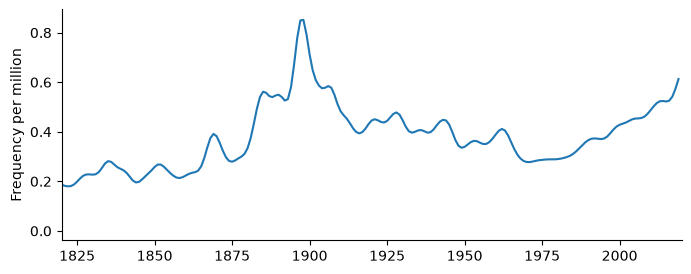

In [3]:
plot_animal('cicada')
plt.xlim(1820, 2020)
plt.show()


### Estimating the periodicity

Periodical cicadas live in groups called broods. Cicada broods have either a 17-year or 13-year lifecycle. A brood naming system was established in 1898 using Roman numeral names. Here are the largest broods for each lifecycle duration:

| Lifecycle Duration | Brood Names      |
|--------------------|------------------|
| 13 years           | XIX, XXII, XXIII |
| 17 years           | II, IV, X, XIV   |

The media will often announce ahead of time when different broods are about to emerge from underground. Can you estimate which lifecycle gets the most attention according to our word usage data?


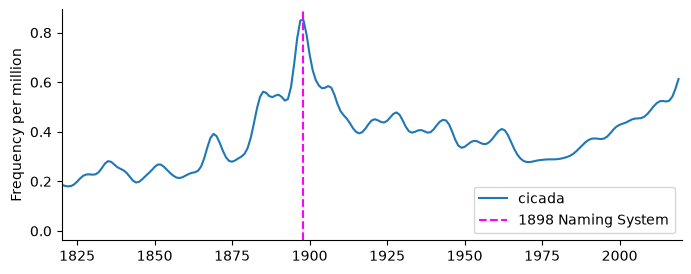

In [4]:
plot_animal('cicada')
plt.xlim(1820, 2020)
plt.axvline(x=1898, color='magenta', linestyle='--', label='1898 Naming System')
plt.legend(loc='lower right')
plt.show()

### Which 17-year brood?
It looks like 17-year cicadas receive the most attention. The four largest 17-year broods are: X, XIV, II, and IV.

We have historical records from 1915 onward for when each of these broods emerged:

| Brood   | Years Emerged             |
|---------|---------------------------|
| Brood X | 1919, 1936, 1953, 1970, 1987, 2004 |
| Brood XIV | 1923, 1940, 1957, 1974, 1991, 2008 |
| Brood II | 1928, 1945, 1962, 1979, 1996, 2013 |
| Brood IV | 1930, 1947, 1964, 1981, 1998, 2015 |

Can we use this data to infer which of these 17-year broods influenced word usage the most? Let's focus on the years from 1915 to 1970, where distinct cyclic peaks and valleys are evident.


In [ ]:
def add_emergence_years( brood_info={} ):
	title = brood_info['title']
	years = brood_info['years']
	for year in years:
		plt.axvline( year, color='magenta', ls=':' )
	plt.title(f'{title}: Years Emerged')

brood_x = {'years': [1919, 1936, 1953], 'title':'Brood X'}
brood_xiv = {'years': [1923,1940,1957], 'title':'Brood XIV'}
brood_ii = {'years': [1928,1945,1962], 'title':'Brood II'}
brood_iv = {'years': [1930,1947,1964], 'title':'Brood IV'}

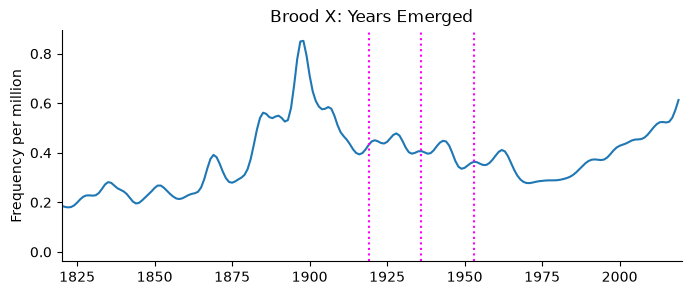

In [ ]:
plot_animal('cicada')
plt.xlim(1820, 2020)
add_emergence_years( brood_x )


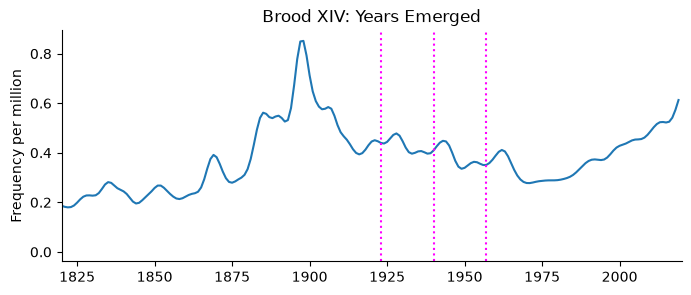

In [7]:
plot_animal('cicada')
plt.xlim(1820, 2020)
add_emergence_years( brood_xiv )
plt.show()

### Observation: Brood XIV

When comparing the emergence years of Brood XIV (marked by the magenta dashed lines) to the word usage trend for 'cicada', we can observe if there's any correlation between their appearances and spikes in public attention as reflected in word usage. This plot helps us visually assess if Brood XIV's emergence patterns correspond to the peaks in the word usage data.

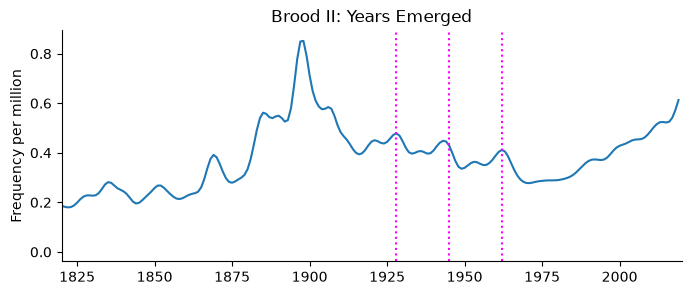

In [8]:
plot_animal('cicada')
plt.xlim(1820, 2020)
add_emergence_years( brood_ii )
plt.show()

### Observation: Brood II

Similarly, this plot overlays the emergence years of Brood II onto the 'cicada' word usage trend. By examining the vertical lines against the frequency peaks, we can determine if Brood II's emergence aligns with increased mentions of 'cicada' in printed materials. This visual comparison aids in identifying potential correlations.

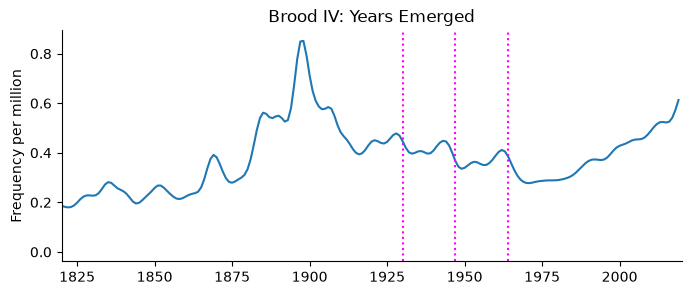

In [9]:
plot_animal('cicada')
plt.xlim(1820, 2020)
add_emergence_years( brood_iv )
plt.show()

### Observation: Brood IV

This final plot in the series presents the emergence years of Brood IV in relation to the 'cicada' word usage data. Observing where the magenta dashed lines fall in conjunction with the spikes in the trend line will help us assess whether Brood IV's emergence events are prominent in public discourse and media attention during the specified period.

### Observations: Comparing 17-year Broods (X, XIV, II, IV)

After plotting all four major 17-year broods (X, XIV, II, and IV) against the 'cicada' word usage data from 1820 to 2020, we can visually assess which brood's emergence years best align with the peaks in word usage.

- **Brood X (1919, 1936, 1953, ...)**: The emergence years for Brood X seem to consistently align with some of the significant peaks in 'cicada' word usage, particularly in the earlier part of the 20th century.
- **Brood XIV (1923, 1940, 1957, ...)**: Brood XIV also shows some alignment with peaks, but perhaps less consistently or with less pronounced peaks compared to Brood X.
- **Brood II (1928, 1945, 1962, ...)**: The emergence years of Brood II appear to coincide with notable increases in word usage, suggesting a strong correlation.
- **Brood IV (1930, 1947, 1964, ...)**: Brood IV's emergence also aligns with certain peaks.

Based on visual inspection, **Brood II and Brood X** appear to have the strongest and most consistent alignment with the peaks in 'cicada' word usage. The spikes in media attention seem to correspond most closely to the emergence years of these two broods, making them strong candidates for the brood that receives the most public attention. This forms our hypothesis to be tested with the actual brood mention data.

### Testing your hypothesis

By aligning historical records with word usage patterns for the word 'cicada', we formed a hypothesis of which cicada brood is discussed the most in the media.

Now let's test our hypothesis by analyzing actual brood mentions in printed materials. First load in the CSV file `cicada-brood-mentions-print.csv`, which contains total mention counts from 1915 to 1970 for each brood.



In [ ]:

broods = pd.read_csv('cicada-brood-mentions-print.csv')
broods 

,brood_name,mentions
0,II,1024
1,X,968
2,XIV,636
3,I,634
4,XIII,348
...,...,...
10,VIII,166
11,IV,160
12,VII,116
13,XXII,100


Now let's generate a bar chart showing the number of mentions for each brood.



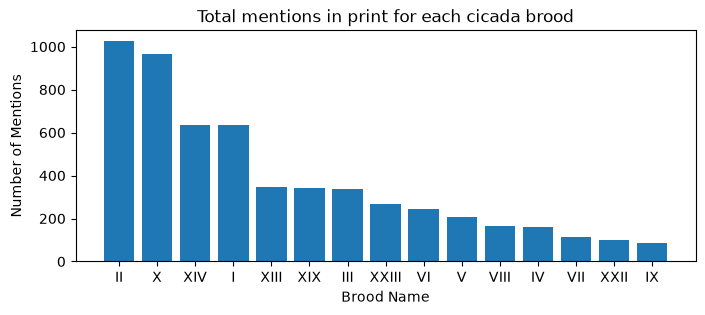

In [11]:
plt.figure(figsize=(8, 3))
plt.bar(broods['brood_name'], broods['mentions'])
plt.xlabel('Brood Name')
plt.ylabel('Number of Mentions')
plt.title('Total mentions in print for each cicada brood')
plt.show()

### Observations: Brood Mentions Bar Chart

The bar chart generated from the `cicada-brood-mentions-print.csv` data displays the total number of mentions for each cicada brood from 1915 to 1970. According to this chart:

- **Brood II** has the highest number of mentions, with 1024 mentions.
- **Brood X** follows closely with 968 mentions.
- **Brood XIV** has 636 mentions.
- Other broods, including 13-year and other 17-year cycles, have significantly fewer mentions.

This quantitative data provides a clear indication of which broods received the most attention in print media during the specified period.

### Does this data support or refute our hypothesis?

Our hypothesis, based on visual inspection of the 'cicada' word usage trends, suggested that **Brood II and Brood X** received the most public attention, as their emergence years most consistently aligned with peaks in the word usage data.

The quantitative data from the `cicada-brood-mentions-print.csv` strongly **supports this hypothesis**.

- The bar chart clearly shows that **Brood II** has the highest number of mentions (1024), followed closely by **Brood X** (968 mentions). This confirms our visual observation that these two broods were indeed the most frequently discussed in print during the period of 1915-1970. The other broods, including XIV and IV, had substantially fewer mentions, aligning with their less prominent visual correlation in the word usage plots.

Therefore, the actual brood mention data validates our visual assessment and hypothesis.

## Conclusion

This project aimed to investigate the multi-year repeating patterns of cicadas by analyzing historical word usage data and comparing it with known cicada brood emergence cycles. We successfully formed and tested hypotheses about which cicada broods receive the most public attention.

**Key Findings:**

1.  **Periodic Patterns in Word Usage:** The analysis of 'cicada' word usage from 1820 to 2020 revealed clear periodic peaks, suggesting a correlation with the emergence of periodical cicadas. The periodicity appeared to be closer to a 17-year cycle than a 13-year cycle.
2.  **Hypothesis Formation (Visual Analysis):** By overlaying the emergence years of the four largest 17-year broods (X, XIV, II, IV) onto the 'cicada' word usage trend, we visually hypothesized that **Brood II and Brood X** were the most prominent, as their emergence years consistently aligned with the most significant spikes in public discourse.
3.  **Hypothesis Testing (Quantitative Data):** To test this hypothesis, we analyzed actual brood mention counts from 1915 to 1970. The bar chart of mentions unequivocally showed that **Brood II had the highest number of mentions (1024), followed by Brood X (968 mentions)**. This quantitative data strongly supported our visual hypothesis.

**Overall Takeaway:**

The project successfully demonstrated a strong correlation between the emergence of specific 17-year periodical cicada broods (Brood II and Brood X) and increased public attention, as evidenced by word usage trends and direct media mentions. This suggests that the biological phenomena of cicada emergences significantly impact human cultural discourse and media coverage, creating observable and predictable patterns in historical data.